# Sensor calibration training

Supports both CSV filename formats:
- `log_<distance>cm.csv` for mixed/up+down data in one file
- `log_<distance>cm_<start>_to_<end>.csv` for legacy directional logs

Direction is parsed only for reference. It is not used as a model feature.

In [103]:
from pathlib import Path
import hashlib
import json
import math
import re
from pprint import pformat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SIMPLE_CSV_RE = re.compile(r'^log_(?P<distance>\d+)cm\.csv$')
RANGED_CSV_RE = re.compile(r'^log_(?P<distance>\d+)cm_(?P<start>\d+(?:\.\d+)?)_to_(?P<end>\d+(?:\.\d+)?)\.csv$')
SENSORS = {
    'mlx90640': 'mlx90640_max',
    'smh01b01': 'smh01b01_max',
    'd6t': 'd6t_raw',
}
REQUIRED_COLUMNS = ['timestamp', 'reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw']

In [104]:
def parse_file_meta(path: Path) -> dict | None:
    simple = SIMPLE_CSV_RE.match(path.name)
    if simple:
        return {
            'source_file': path.name,
            'source_path': str(path.relative_to(ROOT)),
            'distance_cm': int(simple.group('distance')),
            'range_start_c': np.nan,
            'range_end_c': np.nan,
            'direction': 'mixed',
            'filename_format': 'simple',
        }

    ranged = RANGED_CSV_RE.match(path.name)
    if ranged:
        start = float(ranged.group('start'))
        end = float(ranged.group('end'))
        return {
            'source_file': path.name,
            'source_path': str(path.relative_to(ROOT)),
            'distance_cm': int(ranged.group('distance')),
            'range_start_c': start,
            'range_end_c': end,
            'direction': 'up' if start < end else 'down',
            'filename_format': 'ranged',
        }
    return None


def discover_csv_files(root: Path) -> list[Path]:
    seen = set()
    found = []
    for path in root.rglob('*.csv'):
        if any(part in {'.git', '.pio', '.venv', '.venv-1', '__pycache__'} for part in path.parts):
            continue
        resolved = path.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        found.append(path)
    return sorted(found, key=lambda p: str(p.relative_to(root)))


found_files = discover_csv_files(ROOT)
skipped_files = []
seen_content_hashes = {}
frames = []
file_counts = []
for path in found_files:
    meta = parse_file_meta(path)
    if meta is None:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'Unknown filename format'})
        continue
    try:
        content_hash = hashlib.sha256(path.read_bytes()).hexdigest()
    except Exception as exc:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': f'Parse error: {exc}'})
        continue
    if content_hash in seen_content_hashes:
        skipped_files.append({
            'source_path': str(path.relative_to(ROOT)),
            'reason': f'Duplicate file content: {seen_content_hashes[content_hash]}',
        })
        continue
    seen_content_hashes[content_hash] = str(path.relative_to(ROOT))
    try:
        data = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'Empty file'})
        continue
    except Exception as exc:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': f'Parse error: {exc}'})
        continue
    if data.empty:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': 'Empty file'})
        continue
    missing = set(REQUIRED_COLUMNS) - set(data.columns)
    if missing:
        skipped_files.append({'source_path': str(path.relative_to(ROOT)), 'reason': f'Missing required columns: {sorted(missing)}'})
        continue
    data = data[REQUIRED_COLUMNS].copy()
    for key, value in meta.items():
        data[key] = value
    frames.append(data)
    file_counts.append({**meta, 'rows': len(data)})

if not frames:
    raise RuntimeError('No calibration CSV files found')

df = pd.concat(frames, ignore_index=True)
for col in ['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'distance_cm']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

counts_df = pd.DataFrame(file_counts).sort_values(['distance_cm', 'filename_format', 'source_path'])
skipped_df = pd.DataFrame(skipped_files, columns=['source_path', 'reason'])
print(f'Total files found: {len(found_files):,}')
print(f'Total files loaded: {len(counts_df):,}')
print(f'Total rows loaded: {len(df):,}')
print('log_15cm.csv detected:', any(counts_df['source_file'].eq('log_15cm.csv')))
display(counts_df[['source_path', 'distance_cm', 'direction', 'rows']])
display(skipped_df)
display(df.head())

Total files found: 20
Total files loaded: 12
Total rows loaded: 80,005
log_15cm.csv detected: True


,source_path,distance_cm,direction,rows
1,log_15cm_240_to_40.csv,15,down,4865
2,log_15cm_40_to_240.csv,15,up,2332
0,log_15cm.csv,15,mixed,5810
4,log_20cm_240_to_40.csv,20,down,22463
5,log_20cm_40_to_240.csv,20,up,1847
3,log_20cm.csv,20,mixed,7324
7,log_25cm_240_to_40.csv,25,down,11857
8,log_25cm_40_to_240.csv,25,up,2843
6,log_25cm.csv,25,mixed,1954
10,log_30cm_240_to_40.csv,30,down,7908


,source_path,reason
0,log_csv_calib1\log_15cm_240_to_40.csv,Duplicate file content: log_15cm_240_to_40.csv
1,log_csv_calib1\log_15cm_40_to_240.csv,Duplicate file content: log_15cm_40_to_240.csv
2,log_csv_calib1\log_20cm_240_to_40.csv,Duplicate file content: log_20cm_240_to_40.csv
3,log_csv_calib1\log_20cm_40_to_240.csv,Duplicate file content: log_20cm_40_to_240.csv
4,log_csv_calib1\log_25cm_240_to_40.csv,Duplicate file content: log_25cm_240_to_40.csv
5,log_csv_calib1\log_25cm_40_to_240.csv,Duplicate file content: log_25cm_40_to_240.csv
6,log_csv_calib1\log_30cm_240_to_40.csv,Duplicate file content: log_30cm_240_to_40.csv
7,log_csv_calib1\log_30cm_40_to_240.csv,Duplicate file content: log_30cm_40_to_240.csv


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,source_file,source_path,distance_cm,range_start_c,range_end_c,direction,filename_format
0,2026-06-03T13:55:52.042,199.2,211.47,206.8,207.5,log_15cm.csv,log_15cm.csv,15,NaN,NaN,mixed,simple
1,2026-06-03T13:55:52.084,199.2,211.47,206.8,207.5,log_15cm.csv,log_15cm.csv,15,NaN,NaN,mixed,simple
2,2026-06-03T13:55:52.329,199.2,211.47,206.8,207.4,log_15cm.csv,log_15cm.csv,15,NaN,NaN,mixed,simple
3,2026-06-03T13:55:52.499,199.1,211.47,206.8,207.4,log_15cm.csv,log_15cm.csv,15,NaN,NaN,mixed,simple
4,2026-06-03T13:55:53.432,198.9,211.24,206.5,207.1,log_15cm.csv,log_15cm.csv,15,NaN,NaN,mixed,simple


In [105]:
# Debug: print every CSV file discovered by the recursive scan.
from pathlib import Path

for p in sorted(found_files):
    print(p)


c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_15cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_15cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_15cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_20cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_20cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_20cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_25cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_25cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_25cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_30cm.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_30cm_240_to_40.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\log_30cm_40_to_240.csv
c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_te

In [106]:
# Data checks.
display(df[REQUIRED_COLUMNS + ['distance_cm', 'direction']].isna().sum().rename('nan_count').to_frame())
display(df[['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'distance_cm']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

bad = df[
    (~np.isfinite(df[['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw']]).all(axis=1))
    | df['reference_temp'].lt(-40) | df['reference_temp'].gt(350)
    | df[['mlx90640_max', 'smh01b01_max', 'd6t_raw']].lt(-40).any(axis=1)
    | df[['mlx90640_max', 'smh01b01_max', 'd6t_raw']].gt(400).any(axis=1)
]
print(f'Suspicious rows: {len(bad):,}')
display(bad.head(20))

,nan_count
timestamp,0
reference_temp,0
mlx90640_max,0
smh01b01_max,0
d6t_raw,0
distance_cm,0
direction,0


,count,mean,std,min,1%,5%,50%,95%,99%,max
reference_temp,80005.0,105.907911,68.531245,24.60,24.80,25.80,91.00,231.70,241.100,244.40
mlx90640_max,80005.0,110.086330,71.582299,-25.27,30.13,30.55,92.25,242.76,260.362,265.79
smh01b01_max,80005.0,103.872053,69.468372,26.80,27.10,27.50,85.00,234.10,254.400,262.90
d6t_raw,80005.0,97.657093,65.803138,25.60,26.00,26.50,77.30,225.10,234.100,240.00
distance_cm,80005.0,22.566527,5.105662,15.00,15.00,15.00,20.00,30.00,30.000,30.00


Suspicious rows: 0


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,source_file,source_path,distance_cm,range_start_c,range_end_c,direction,filename_format


C:\Users\admin\AppData\Local\Temp\ipykernel_30756\156259060.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


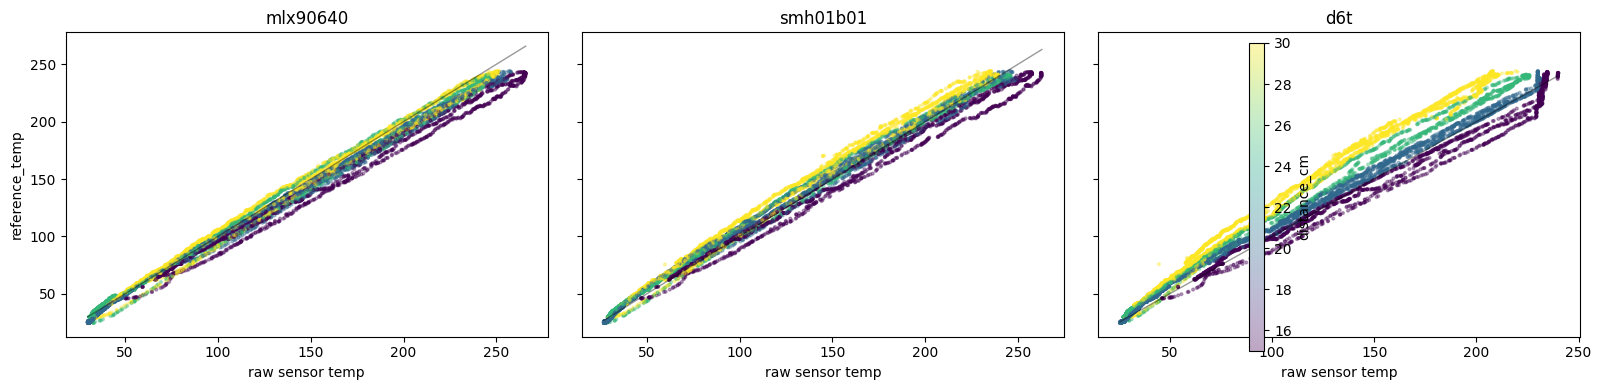

In [107]:
# Quick plots: sensor raw vs reference.
plot_df = df.sample(min(len(df), 12000), random_state=7) if len(df) > 12000 else df
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (sensor, col) in zip(axes, SENSORS.items()):
    sc = ax.scatter(plot_df[col], plot_df['reference_temp'], c=plot_df['distance_cm'], s=4, alpha=0.35, cmap='viridis')
    ax.plot([plot_df[col].min(), plot_df[col].max()], [plot_df[col].min(), plot_df[col].max()], color='black', lw=1, alpha=0.4)
    ax.set_title(sensor)
    ax.set_xlabel('raw sensor temp')
axes[0].set_ylabel('reference_temp')
fig.colorbar(sc, ax=axes, label='distance_cm')
plt.tight_layout()

In [108]:
# Raw differences against reference.
df['diff_mlx90640'] = df['mlx90640_max'] - df['reference_temp']
df['diff_smh01b01'] = df['smh01b01_max'] - df['reference_temp']
df['diff_d6t'] = df['d6t_raw'] - df['reference_temp']
display(df.groupby(['distance_cm', 'direction'])[['diff_mlx90640', 'diff_smh01b01', 'diff_d6t']].agg(['mean', 'std', 'min', 'max']))

diff_mlx90640                         diff_smh01b01  \
                               mean       std    min    max          mean   
distance_cm direction                                                       
15          down           5.200987  2.994220 -33.29  17.88     -0.378705   
            mixed         14.452312  5.400765   3.20  25.57      7.586540   
            up            22.583070  5.885264   4.10  31.55     17.528774   
20          down           3.165039  2.467042 -90.57  15.00     -1.540177   
            mixed          6.356402  4.664813  -0.40  19.72     -1.004601   
            up             8.133557  2.930671  -1.72  14.00     -2.273470   
25          down          -1.234436  1.907691  -6.28   5.04     -4.758986   
            mixed          9.272226  4.143446  -0.73  14.39     -2.520522   
            up             6.781382  2.060392   2.54  12.30      3.096201   
30          down          -2.696108  2.620675 -46.46   7.80     -9.824279   
            mixed          2.143760  3.696061  -3.92  13.39     -7.645601   
            up             8.486742  1.453261   4.25  14.53     -2.185078   

                                              diff_d6t                         
                            std   min   max       mean        std   min   max  
distance_cm direction                                                          
15          down       2.774351  -3.2  12.6  -0.232518   3.726796  -8.3  11.3  
            mixed      4.592135  -1.4  17.4   5.857745   6.391828  -8.7  18.2  
            up         6.784980  -0.9  28.1  13.928774   8.287490  -4.6  25.8  
20          down       4.189087 -10.7   4.0  -2.850367   4.509885 -14.3   2.0  
            mixed      4.694013  -7.5  13.3  -5.896232   2.868723 -11.4   1.6  
            up         2.383041 -10.3   3.0  -2.405468   3.533506 -12.9   2.4  
25          down       2.834731 -12.6   2.1 -10.931652   7.365875 -28.6  -0.9  
            mixed      2.873163 -10.1   2.1 -13.475537   1.828156 -16.1  -7.2  
            up         1.806022  -3.1   7.3 -13.240098   5.818094 -23.4   4.0  
30          down       4.926102 -25.3  -2.3 -19.279843  10.243571 -49.5  -5.3  
            mixed      3.986653 -15.7   3.0 -24.895500   8.015924 -37.3  -9.4  
            up         3.632996 -10.9   5.9 -24.416562  12.664772 -42.5   2.4

In [109]:
MODEL_SPECS = [
    ('linear_raw', 1, ['raw']),
    ('poly2_raw', 2, ['raw']),
    ('poly3_raw', 3, ['raw']),
    ('poly2_raw_distance', 2, ['raw', 'distance_cm']),
    ('poly3_raw_distance', 3, ['raw', 'distance_cm']),
]


def feature_frame(data: pd.DataFrame, raw_col: str, features: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=data.index)
    for feature in features:
        out[feature] = data[raw_col] if feature == 'raw' else data[feature]
    return out


def deterministic_holdout(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    order = data.groupby('source_path').cumcount()
    test_mask = order.mod(5).eq(0)
    return data.loc[~test_mask].copy(), data.loc[test_mask].copy()


def evaluate_model(sensor: str, raw_col: str, name: str, degree: int, features: list[str]) -> tuple[dict, Pipeline]:
    clean = df.dropna(subset=['reference_temp', raw_col, 'distance_cm']).copy()
    train, test = deterministic_holdout(clean)
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('linear', LinearRegression(fit_intercept=False)),
    ])
    model.fit(feature_frame(train, raw_col, features), train['reference_temp'])
    pred = model.predict(feature_frame(test, raw_col, features))
    eval_df = test[['reference_temp', 'distance_cm', 'direction']].copy()
    eval_df['pred'] = pred
    by_distance = {
        int(distance): float(mean_absolute_error(group['reference_temp'], group['pred']))
        for distance, group in eval_df.groupby('distance_cm')
    }
    row = {
        'sensor': sensor,
        'model': name,
        'degree': degree,
        'features': features,
        'MAE': float(mean_absolute_error(test['reference_temp'], pred)),
        'RMSE': float(np.sqrt(mean_squared_error(test['reference_temp'], pred))),
        'R2': float(r2_score(test['reference_temp'], pred)),
        'MAE_by_distance': by_distance,
        'distance_mae_span': float(max(by_distance.values()) - min(by_distance.values())) if by_distance else np.nan,
        'n_coefficients': int(len(model.named_steps['linear'].coef_)),
    }
    for direction in ['up', 'down', 'mixed']:
        subset = eval_df[eval_df['direction'].eq(direction)]
        row[f'MAE_{direction}'] = float(mean_absolute_error(subset['reference_temp'], subset['pred'])) if len(subset) else np.nan
    row['selection_score'] = row['RMSE'] + 0.10 * row['distance_mae_span'] + 0.002 * row['n_coefficients']
    return row, model


rows = []
for sensor, raw_col in SENSORS.items():
    for name, degree, features in MODEL_SPECS:
        row, _ = evaluate_model(sensor, raw_col, name, degree, features)
        rows.append(row)

results = pd.DataFrame(rows).sort_values(['sensor', 'selection_score'])
display(results[['sensor', 'model', 'MAE', 'RMSE', 'R2', 'MAE_up', 'MAE_down', 'MAE_mixed', 'MAE_by_distance', 'distance_mae_span', 'n_coefficients', 'selection_score']])

,sensor,model,MAE,RMSE,R2,MAE_up,MAE_down,MAE_mixed,MAE_by_distance,distance_mae_span,n_coefficients,selection_score
13,d6t,poly2_raw_distance,3.272626,4.666733,0.995364,6.762464,2.385848,3.652293,"{15: 5.951983419927697, 20: 2.297811150136161,...",3.654172,6,5.044150
14,d6t,poly3_raw_distance,3.464632,4.683908,0.995330,6.006359,2.596137,4.187085,"{15: 6.998504937985943, 20: 2.426658110602057,...",4.571847,10,5.161092
12,d6t,poly3_raw,7.982851,10.684840,0.975700,12.692957,5.517165,11.036719,"{15: 15.261612404763353, 20: 4.320281496267146...",11.048598,4,11.797700
11,d6t,poly2_raw,7.709582,10.610950,0.976035,12.721335,5.046284,11.038552,"{15: 15.512650863648997, 20: 3.526044449389032...",11.986606,3,11.815611
10,d6t,linear_raw,8.752690,11.599651,0.971361,13.604050,6.532326,11.258659,"{15: 14.683840269395848, 20: 4.978846575319284...",9.704994,2,12.574151
3,mlx90640,poly2_raw_distance,2.965861,3.810815,0.996909,5.297130,2.422654,3.120987,"{15: 4.383450038070784, 20: 2.1059033190568406...",2.277547,6,4.050570
4,mlx90640,poly3_raw_distance,3.717628,4.943738,0.994798,5.498182,3.065303,4.311694,"{15: 6.308692467586601, 20: 2.818976337697693,...",3.489716,10,5.312710
2,mlx90640,poly3_raw,3.989259,5.177295,0.994295,6.503691,3.250816,4.462141,"{15: 6.145453131728777, 20: 2.616424966623807,...",3.529028,4,5.538198
1,mlx90640,poly2_raw,3.847848,5.130664,0.994397,6.590596,2.981046,4.486468,"{15: 6.412891362121143, 20: 2.172213282277513,...",4.240678,3,5.560732
0,mlx90640,linear_raw,4.154979,5.433712,0.993716,5.861510,3.565645,4.652497,"{15: 6.2210778461786385, 20: 2.990113953337529...",3.230964,2,5.760809


In [110]:
def choose_best(group: pd.DataFrame) -> pd.Series:
    best_rmse = group['RMSE'].min()
    close = group[group['RMSE'].le(best_rmse * 1.02 + 0.05)].copy()
    return close.sort_values(['n_coefficients', 'selection_score']).iloc[0]


selected_rows = []
for sensor_name, group in results.groupby('sensor'):
    row = choose_best(group).copy()
    row['sensor'] = sensor_name
    selected_rows.append(row)
selected = pd.DataFrame(selected_rows).reset_index(drop=True)
if 'sensor' not in selected.columns:
    selected = selected.reset_index().rename(columns={'index': 'sensor'})
display(selected[['sensor', 'model', 'features', 'MAE', 'RMSE', 'R2', 'MAE_by_distance']])

,sensor,model,features,MAE,RMSE,R2,MAE_by_distance
0,d6t,poly2_raw_distance,"[raw, distance_cm]",3.272626,4.666733,0.995364,"{15: 5.951983419927697, 20: 2.297811150136161,..."
1,mlx90640,poly2_raw_distance,"[raw, distance_cm]",2.965861,3.810815,0.996909,"{15: 4.383450038070784, 20: 2.1059033190568406..."
2,smh01b01,poly2_raw_distance,"[raw, distance_cm]",3.041003,4.009942,0.996577,"{15: 4.535071038942255, 20: 2.6085714640566926..."


In [111]:
def export_profile(sensor: str, raw_col: str, model_name: str, degree: int, features: list[str]) -> dict:
    clean = df.dropna(subset=['reference_temp', raw_col, 'distance_cm']).copy()
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('linear', LinearRegression(fit_intercept=False)),
    ])
    X = feature_frame(clean, raw_col, features)
    model.fit(X, clean['reference_temp'])
    poly = model.named_steps['poly']
    linear = model.named_steps['linear']
    return {
        'model_name': model_name,
        'degree': int(degree),
        'features': features,
        'powers': poly.powers_.astype(int).tolist(),
        'coefficients': [float(x) for x in linear.coef_],
        'uses_direction': False,
    }


profiles = {}
for _, row in selected.iterrows():
    profiles[row['sensor']] = export_profile(row['sensor'], SENSORS[row['sensor']], row['model'], int(row['degree']), list(row['features']))

runtime_template = f'''\
"""
Polynomial calibration profiles exported from notebooks/train_calibration.ipynb.

Runtime intentionally depends only on the Python standard library.
"""

from __future__ import annotations

import logging
import math

logger = logging.getLogger("calib")


CALIB_PROFILES = {pformat(profiles, width=100)}


def calibrate(sensor_name: str, raw_value: float, distance_cm: int | float | None, direction=None) -> float:
    profile = CALIB_PROFILES.get(sensor_name)
    try:
        raw = float(raw_value)
    except (TypeError, ValueError):
        logger.warning("[CALIB] invalid raw value for sensor=%s, using raw value", sensor_name)
        return raw_value

    if profile is None:
        logger.warning("[CALIB] profile not found, using raw value")
        return raw
    if not math.isfinite(raw):
        return raw

    values = []
    for feature in profile["features"]:
        if feature == "raw":
            values.append(raw)
        elif feature == "distance_cm":
            if distance_cm is None:
                logger.warning("[CALIB] distance_cm missing for sensor=%s, using raw value", sensor_name)
                return raw
            values.append(float(distance_cm))
        else:
            logger.warning("[CALIB] unknown feature=%s for sensor=%s, using raw value", feature, sensor_name)
            return raw

    result = 0.0
    for coefficient, powers in zip(profile["coefficients"], profile["powers"]):
        term = float(coefficient)
        for value, power in zip(values, powers):
            if power:
                term *= value ** int(power)
        result += term
    return float(result) if math.isfinite(result) else raw
'''

out_path = ROOT / 'src' / 'calib_profiles.py'
out_path.write_text(runtime_template, encoding='utf-8')
print(f'Exported {out_path}')
print('direction_code in exported profiles:', 'direction_code' in runtime_template)
print(json.dumps(profiles, indent=2))

Exported c:\Users\admin\Documents\PlatformIO\Projects\Test_cam_temp\src\calib_profiles.py
direction_code in exported profiles: False
{
  "d6t": {
    "model_name": "poly2_raw_distance",
    "degree": 2,
    "features": [
      "raw",
      "distance_cm"
    ],
    "powers": [
      [
        0,
        0
      ],
      [
        1,
        0
      ],
      [
        0,
        1
      ],
      [
        2,
        0
      ],
      [
        1,
        1
      ],
      [
        0,
        2
      ]
    ],
    "coefficients": [
      -16.92450271847372,
      0.9745090637076343,
      0.6589181844258359,
      -0.0006825904996607957,
      0.010745195446769829,
      -0.001792696462029092
    ],
    "uses_direction": false
  },
  "mlx90640": {
    "model_name": "poly2_raw_distance",
    "degree": 2,
    "features": [
      "raw",
      "distance_cm"
    ],
    "powers": [
      [
        0,
        0
      ],
      [
        1,
        0
      ],
      [
        0,
        1
      ],
  